In [1]:
# pip install openpyxl

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [3]:
pt = 'https://raw.githubusercontent.com/Paingst12/Flight-Price-Analysis-scikit-learn-Pandas-Numpy-Matplotlib-Seaborn-/main/flight_price.xlsx'

df = pd.read_excel(pt)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Airline          10683 non-null  str  
 1   Date_of_Journey  10683 non-null  str  
 2   Source           10683 non-null  str  
 3   Destination      10683 non-null  str  
 4   Route            10682 non-null  str  
 5   Dep_Time         10683 non-null  str  
 6   Arrival_Time     10683 non-null  str  
 7   Duration         10683 non-null  str  
 8   Total_Stops      10682 non-null  str  
 9   Additional_Info  10683 non-null  str  
 10  Price            10683 non-null  int64
dtypes: int64(1), str(10)
memory usage: 918.2 KB


In [5]:
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [6]:
# Convert 'Date_of_Journey' to datetime object first, if not already
df['Date_of_Journey'] = pd.to_datetime(df['Date_of_Journey'], format='%d/%m/%Y')

# Extract Day, Month, and Year correctly from the original 'Date_of_Journey' string if needed,
# or from the datetime object. Assuming Date_of_Journey is already converted, we can extract from it.
df['Day'] = df['Date_of_Journey'].dt.day
df['Month'] = df['Date_of_Journey'].dt.month
df['Year'] = df['Date_of_Journey'].dt.year

# The 'Date' column was created previously and is still an object (string)
# Convert the 'Date' column to datetime as requested by the user
# df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')

# Display the updated info and head to verify
print(df.info())
display(df.head())

<class 'pandas.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Airline          10683 non-null  str           
 1   Date_of_Journey  10683 non-null  datetime64[us]
 2   Source           10683 non-null  str           
 3   Destination      10683 non-null  str           
 4   Route            10682 non-null  str           
 5   Dep_Time         10683 non-null  str           
 6   Arrival_Time     10683 non-null  str           
 7   Duration         10683 non-null  str           
 8   Total_Stops      10682 non-null  str           
 9   Additional_Info  10683 non-null  str           
 10  Price            10683 non-null  int64         
 11  Day              10683 non-null  int32         
 12  Month            10683 non-null  int32         
 13  Year             10683 non-null  int32         
dtypes: datetime64[us](1), int32(3), int64(1), str(9)


,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Day,Month,Year
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3,2019
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,1,5,2019
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882,9,6,2019
3,IndiGo,2019-05-12,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218,12,5,2019
4,IndiGo,2019-03-01,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302,1,3,2019


In [7]:
df['Arrival_Time'].unique()

<StringArray>
['01:10 22 Mar',        '13:15', '04:25 10 Jun',        '23:30',
        '21:35',        '11:25', '10:25 13 Mar', '05:05 02 Mar',
        '19:15',        '23:00',
 ...
 '00:50 25 Jun', '00:50 19 Jun', '05:35 10 May', '02:10 22 Mar',
 '03:35 28 Apr', '00:50 28 Jun', '22:40 07 Jun', '06:50 10 Mar',
 '00:05 19 Mar', '21:20 13 Mar']
Length: 1343, dtype: str

In [8]:
df['Arrival_Time']= df['Arrival_Time'].apply(lambda x: x.split(' ')[0])

In [9]:
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Day,Month,Year
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,22:20,01:10,2h 50m,non-stop,No info,3897,24,3,2019
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,1,5,2019
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25,19h,2 stops,No info,13882,9,6,2019
3,IndiGo,2019-05-12,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218,12,5,2019
4,IndiGo,2019-03-01,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302,1,3,2019


In [10]:
df = df.rename(columns={'Arrival_Time': 'Avl_Time'})

# Display the updated info and head to verify
print(df.info())
display(df.head())

<class 'pandas.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Airline          10683 non-null  str           
 1   Date_of_Journey  10683 non-null  datetime64[us]
 2   Source           10683 non-null  str           
 3   Destination      10683 non-null  str           
 4   Route            10682 non-null  str           
 5   Dep_Time         10683 non-null  str           
 6   Avl_Time         10683 non-null  str           
 7   Duration         10683 non-null  str           
 8   Total_Stops      10682 non-null  str           
 9   Additional_Info  10683 non-null  str           
 10  Price            10683 non-null  int64         
 11  Day              10683 non-null  int32         
 12  Month            10683 non-null  int32         
 13  Year             10683 non-null  int32         
dtypes: datetime64[us](1), int32(3), int64(1), str(9)


,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Avl_Time,Duration,Total_Stops,Additional_Info,Price,Day,Month,Year
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,22:20,01:10,2h 50m,non-stop,No info,3897,24,3,2019
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,1,5,2019
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25,19h,2 stops,No info,13882,9,6,2019
3,IndiGo,2019-05-12,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218,12,5,2019
4,IndiGo,2019-03-01,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302,1,3,2019


In [11]:
df['Total_Stops'].unique()

<StringArray>
['non-stop', '2 stops', '1 stop', '3 stops', nan, '4 stops']
Length: 6, dtype: str

In [12]:
stop_map = {'non-stop': 0, '1 stop': 1, '2 stops': 2, '3 stops': 3, '4 stops': 4}
df['Total_Stops'] = df['Total_Stops'].map(stop_map)

In [13]:
df[df.isnull().any(axis=1)]

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Avl_Time,Duration,Total_Stops,Additional_Info,Price,Day,Month,Year
9039,Air India,2019-05-06,Delhi,Cochin,NaN,09:45,09:25,23h 40m,NaN,No info,7480,6,5,2019


In [14]:
df['Total_Stops'] = df['Total_Stops'].replace(np.nan, 0)

In [15]:
df['Route'].unique()

<StringArray>
[                        'BLR → DEL',             'CCU → IXR → BBI → BLR',
             'DEL → LKO → BOM → COK',                   'CCU → NAG → BLR',
                   'BLR → NAG → DEL',                         'CCU → BLR',
                   'BLR → BOM → DEL',                   'DEL → BOM → COK',
                   'DEL → BLR → COK',                         'MAA → CCU',
 ...
                   'BOM → BLR → HYD',                   'BLR → STV → DEL',
             'CCU → IXB → DEL → BLR',             'BOM → JAI → DEL → HYD',
             'BOM → VNS → DEL → HYD',       'BLR → HBX → BOM → NAG → DEL',
                                 nan,             'BLR → BOM → IXC → DEL',
 'BLR → CCU → BBI → HYD → VGA → DEL',                   'BOM → BBI → HYD']
Length: 129, dtype: str

In [16]:
df['Total_Stops'].value_counts()

Total_Stops
1.0    5625
0.0    3492
2.0    1520
3.0      45
4.0       1
Name: count, dtype: int64

In [17]:
df['Airline'].unique()

<StringArray>
[                           'IndiGo',                         'Air India',
                       'Jet Airways',                          'SpiceJet',
                 'Multiple carriers',                             'GoAir',
                           'Vistara',                          'Air Asia',
           'Vistara Premium economy',              'Jet Airways Business',
 'Multiple carriers Premium economy',                            'Trujet']
Length: 12, dtype: str

In [18]:
df['Source'].unique()

<StringArray>
['Banglore', 'Kolkata', 'Delhi', 'Chennai', 'Mumbai']
Length: 5, dtype: str

In [19]:
def duration_to_minutes(duration_str):
    parts = duration_str.split()
    hours, minutes = 0, 0
    for part in parts:
        if 'h' in part:
            hours = int(part.replace('h', ''))
        elif 'm' in part:
            minutes = int(part.replace('m', ''))
    return hours * 60 + minutes

df['Duration_Min'] = df['Duration'].apply(duration_to_minutes)


In [20]:
print(df[['Duration_Min','Price']].corr())

              Duration_Min     Price
Duration_Min      1.000000  0.506371
Price             0.506371  1.000000


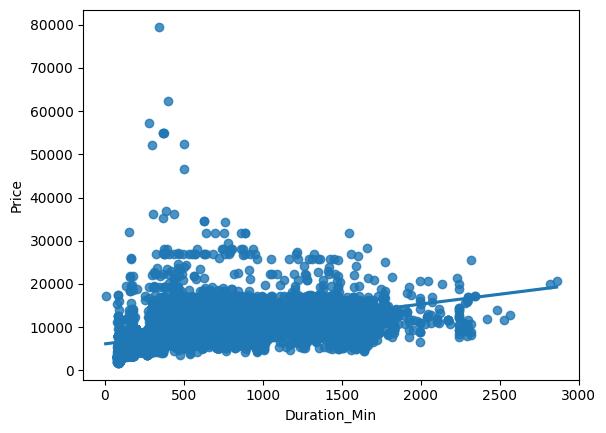

In [21]:

sns.regplot(x='Duration_Min', y='Price', data=df)
plt.show()

In [22]:
conditions = [
    df['Duration_Min'] <= 720,
    (df['Duration_Min'] > 720) & (df['Duration_Min'] <= 1440),
    (df['Duration_Min'] > 1440) & (df['Duration_Min'] <= 2160),
    df['Duration_Min'] > 2160
]
choices = ['short-travel flight', 'normal flight', 'long flight', 'overnight flight']
df['Travel_Type'] = np.select(conditions, choices, default='Unknown')

# Display the value counts for the new column and a sample of the DataFrame
print(df['Travel_Type'].value_counts())
display(df.head())

Travel_Type
short-travel flight    6693
normal flight          2897
long flight            1027
overnight flight         66
Name: count, dtype: int64


,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Avl_Time,Duration,Total_Stops,Additional_Info,Price,Day,Month,Year,Duration_Min,Travel_Type
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,22:20,01:10,2h 50m,0.0,No info,3897,24,3,2019,170,short-travel flight
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2.0,No info,7662,1,5,2019,445,short-travel flight
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25,19h,2.0,No info,13882,9,6,2019,1140,normal flight
3,IndiGo,2019-05-12,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1.0,No info,6218,12,5,2019,325,short-travel flight
4,IndiGo,2019-03-01,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1.0,No info,13302,1,3,2019,285,short-travel flight



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


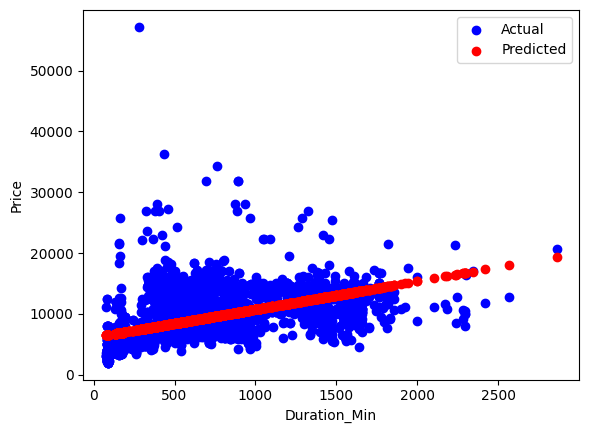

R-squared: 0.24838483552768997


In [23]:
%pip install scikit-learn
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

x = df[['Duration_Min']]
y = df['Price']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

lm = LinearRegression()
lm.fit(x_train, y_train)

y_pred = lm.predict(x_test)

plt.scatter(x_test, y_test, color='blue', label='Actual')
plt.scatter(x_test, y_pred, color='red', label='Predicted')
plt.xlabel('Duration_Min')
plt.ylabel('Price')
plt.legend()
plt.show()

r2 = r2_score(y_test, y_pred)
print(f'R-squared: {r2}')

## Conclusion: Regression Model Evaluation (R² Score Analysis)
The R² score (0.248) indicates that the regression model explains approximately 24.8% of the variation in Price based on Duration (minutes). Here’s what this means:

- Low Predictive Power: A score of 0.248 suggests that the model does not strongly capture the relationship between Duration_mins and Price.
- Possible Missing Factors: Other variables besides duration may significantly influence price, such as demand, service type, location, or seasonal trends.
- Actual vs Predicted Scatter Plot: The visualization shows a clear gap between actual values (blue dots) and predicted values (red dots), indicating potential errors or limitations in the model’s fit.
- Improvements Needed: Consider incorporating additional predictive variables, trying non-linear regression models, or fine-tuning the feature selection process for better accuracy.


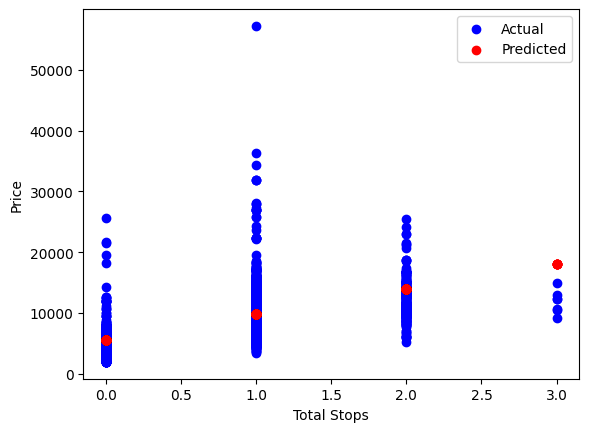

R-squared: 0.3423245486959211


In [24]:
x = df[['Total_Stops']]
y = df['Price']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

lm = LinearRegression()
lm.fit(x_train, y_train)

y_pred = lm.predict(x_test)

plt.scatter(x_test['Total_Stops'], y_test, color='blue', label='Actual')
plt.scatter(x_test['Total_Stops'], y_pred, color='red', label='Predicted')
plt.xlabel('Total Stops')
plt.ylabel('Price')
plt.legend()
plt.show()

r2 = r2_score(y_test, y_pred)
print(f'R-squared: {r2}')

## Price
The scatter plot compares actual and predicted prices against the number of total stops for flights, providing insight into the model’s effectiveness. The R² score of 0.342 indicates that the regression model explains only 34.2% of the variation in price based on total stops.
Key Observations:
- The actual and predicted prices show visible deviations, indicating the model may struggle to capture all influencing factors.
- While there is some alignment between actual (blue) and predicted (red) points, inconsistencies suggest missing features or nonlinear relationships.
- Total stops do impact flight prices, but likely not the only factor—other variables such as airline, route, demand fluctuations, and booking time may significantly affect pricing.
- A low R² score implies that the model only partially explains price variations, meaning further refinement is needed for better predictions


In [25]:
print(df[['Total_Stops','Price']].corr())

             Total_Stops     Price
Total_Stops     1.000000  0.603891
Price           0.603891  1.000000


## Conclusion: Relationship Between Total Stops and Price
From the scatter plot and correlation matrix, we analyze the impact of total stops on flight pricing. The findings show:
- Moderate Positive Correlation (0.603883)
    - This suggests that as the number of stops increases, the flight price tends to rise.
- Scatter Plot Trend
    - The plotted points display an upward trend, reinforcing the correlation between stops and price.
    - The variation in price for the same number of stops hints at additional influencing factors beyond just stop count.
- Data Distribution & Variability
    - A spread in price values indicates that other variables—such as airline type, time of booking, and demand—also affect pricing.
    - The correlation isn't perfect (not near 1.0), meaning while stops do influence price, they are not the sole determinant.


In [26]:
X = df[['Duration_Min', 'Total_Stops']]
y = df['Price']

# 3. Train set (80%) နှင့် Test set (20%) ခွဲထုတ်ခြင်း
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Multiple Linear Regression Model တည်ဆောက်၍ လေ့ကျင့်ပေးခြင်း
mlm = LinearRegression()
mlm.fit(X_train, y_train)

# 5. Test Data ဖြင့် ဈေးနှုန်း ခန့်မှန်းခြင်း
y_pred = mlm.predict(X_test)

# 6. R^2 Score တွက်ချက်ခြင်း
r2 = r2_score(y_test, y_pred)
print("R^2 score (Duration_mins + Stops_num vs Price):", r2)

# Model ရဲ့ Coefficients (Equation Equation အတွက် တွက်ချက်ချက်များ)
print("\n--- Model Coefficients ---")
print(f"Duration_mins (Increase in Price per Minute) : {mlm.coef_[0]:.2f}")
print(f"Stops_num (Increase in Price per Stop )      : {mlm.coef_[1]:.2f}")
print(f"Intercept (Baseline Flight Ticket Price)            : {mlm.intercept_:.2f}")

R^2 score (Duration_mins + Stops_num vs Price): 0.3505721290787711

--- Model Coefficients ---
Duration_mins (Increase in Price per Minute) : 1.21
Stops_num (Increase in Price per Stop )      : 3493.09
Intercept (Baseline Flight Ticket Price)            : 5426.36


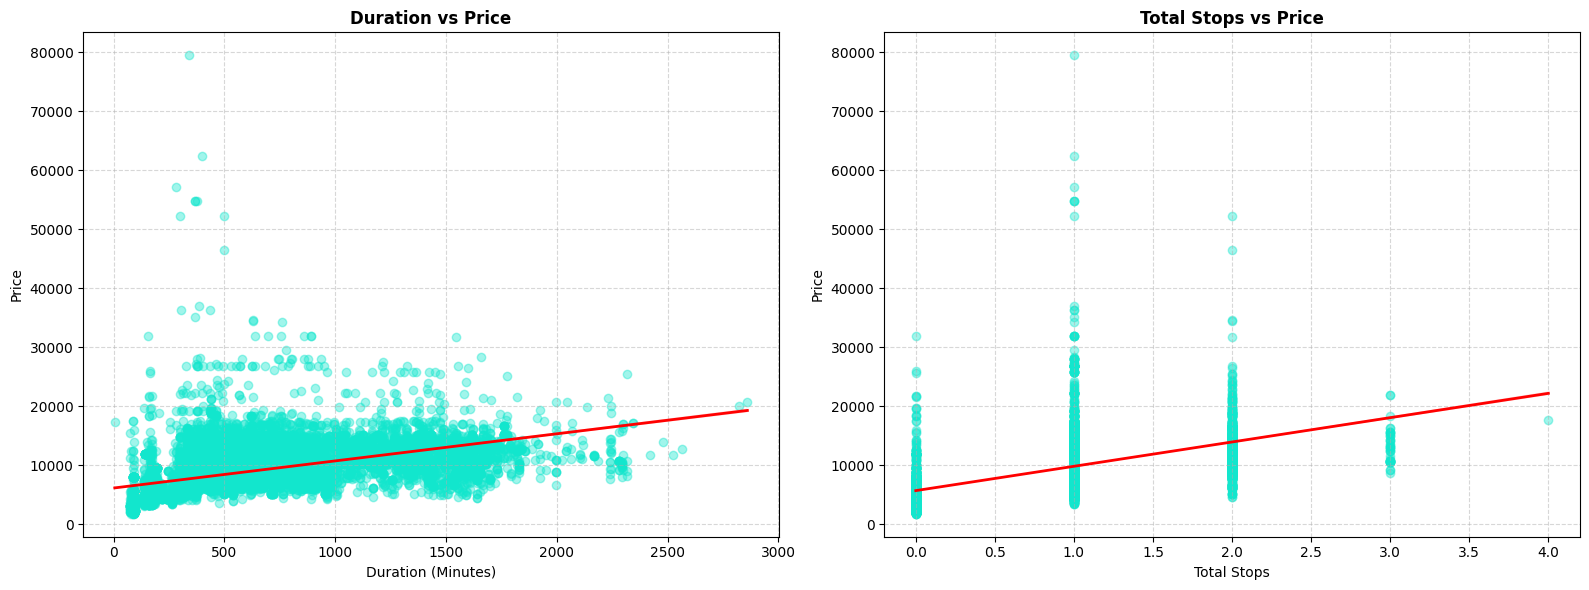

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. ပထမ Graph (Duration vs Price) -> ax=axes[0] တွင် ဆွဲမည်
sns.regplot(
    data=df,
    x='Duration_Min',
    y='Price',
    ax=axes[0],
    scatter_kws={'color': '#12E6CD', 'alpha': 0.4},
    line_kws={'color': 'red', 'linewidth': 2}
)
axes[0].set_title('Duration vs Price', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Duration (Minutes)')
axes[0].set_ylabel('Price')
axes[0].grid(True, linestyle='--', alpha=0.5)

# 2. ဒုတိယ Graph (Total_Stops vs Price) -> ax=axes[1] တွင် ဆွဲမည်
# (Stops_num သည် Total_Stops မှ ပြောင်းထားသော Integer Column ဖြစ်ရပါမည်)
sns.regplot(
    data=df,
    x='Total_Stops',
    y='Price',
    ax=axes[1],
    scatter_kws={'color': '#12E6CD', 'alpha': 0.4},
    line_kws={'color': 'red', 'linewidth': 2}
)
axes[1].set_title('Total Stops vs Price', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Total Stops')
axes[1].set_ylabel('Price')
axes[1].grid(True, linestyle='--', alpha=0.5)

# Graph စာသားများ မထပ်အောင် ဘေးဘောင် ညှိပေးခြင်း
plt.tight_layout()
plt.show()

In [28]:
df['Total_Stops'] = df['Total_Stops'].astype(int)
display(df.head())
df.info()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Avl_Time,Duration,Total_Stops,Additional_Info,Price,Day,Month,Year,Duration_Min,Travel_Type
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,22:20,01:10,2h 50m,0,No info,3897,24,3,2019,170,short-travel flight
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2,No info,7662,1,5,2019,445,short-travel flight
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25,19h,2,No info,13882,9,6,2019,1140,normal flight
3,IndiGo,2019-05-12,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1,No info,6218,12,5,2019,325,short-travel flight
4,IndiGo,2019-03-01,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1,No info,13302,1,3,2019,285,short-travel flight


<class 'pandas.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Airline          10683 non-null  str           
 1   Date_of_Journey  10683 non-null  datetime64[us]
 2   Source           10683 non-null  str           
 3   Destination      10683 non-null  str           
 4   Route            10682 non-null  str           
 5   Dep_Time         10683 non-null  str           
 6   Avl_Time         10683 non-null  str           
 7   Duration         10683 non-null  str           
 8   Total_Stops      10683 non-null  int64         
 9   Additional_Info  10683 non-null  str           
 10  Price            10683 non-null  int64         
 11  Day              10683 non-null  int32         
 12  Month            10683 non-null  int32         
 13  Year             10683 non-null  int32         
 14  Duration_Min     10683 non-null  int64         
 

In [29]:
bin = [0, 4*60, 8*60, 12*60, 16*60, 20*60, 24*60]
labels = ['0-4 hrs', '4-8 hrs', '8-12 hrs', '12-16 hrs', '16-20 hrs', '20-24 hrs']

df['Duration_Bin'] = pd.cut(df['Duration_Min'], bins=bin, labels=labels, right=True, include_lowest=True)
# right=True: အပိုင်းအခြားရဲ့ ညာဘက်အစွန်းတန်ဖိုး ပါဝင်မည်ဟု အဓိပ္ပာယ်ရပါသည်
# (ဥပမာ- (0, 240] ဆိုလျှင် 240 မိနစ်အတိအကျသည် '0-4' အုပ်စုထဲ ပါပါမည်)။
# include_lowest=True: အသေးငယ်ဆုံးတန်ဖိုး (ဥပမာ- 0 မိနစ်) ကိုပါ အုပ်စုထဲ အကျုံးဝင်စေပါတယ်။

# Display the value counts for the new column and a sample of the DataFrame
print(df['Duration_Bin'].value_counts())
display(df.head())

Duration_Bin
0-4 hrs      3537
4-8 hrs      1586
8-12 hrs     1570
12-16 hrs    1410
20-24 hrs     846
16-20 hrs     641
Name: count, dtype: int64


,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Avl_Time,Duration,Total_Stops,Additional_Info,Price,Day,Month,Year,Duration_Min,Travel_Type,Duration_Bin
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,22:20,01:10,2h 50m,0,No info,3897,24,3,2019,170,short-travel flight,0-4 hrs
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2,No info,7662,1,5,2019,445,short-travel flight,4-8 hrs
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25,19h,2,No info,13882,9,6,2019,1140,normal flight,16-20 hrs
3,IndiGo,2019-05-12,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1,No info,6218,12,5,2019,325,short-travel flight,4-8 hrs
4,IndiGo,2019-03-01,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1,No info,13302,1,3,2019,285,short-travel flight,4-8 hrs


In [30]:
df['Duration_Bin'].dtype


CategoricalDtype(categories=['0-4 hrs', '4-8 hrs', '8-12 hrs', '12-16 hrs', '16-20 hrs',
                  '20-24 hrs'],
, ordered=True, categories_dtype=str)

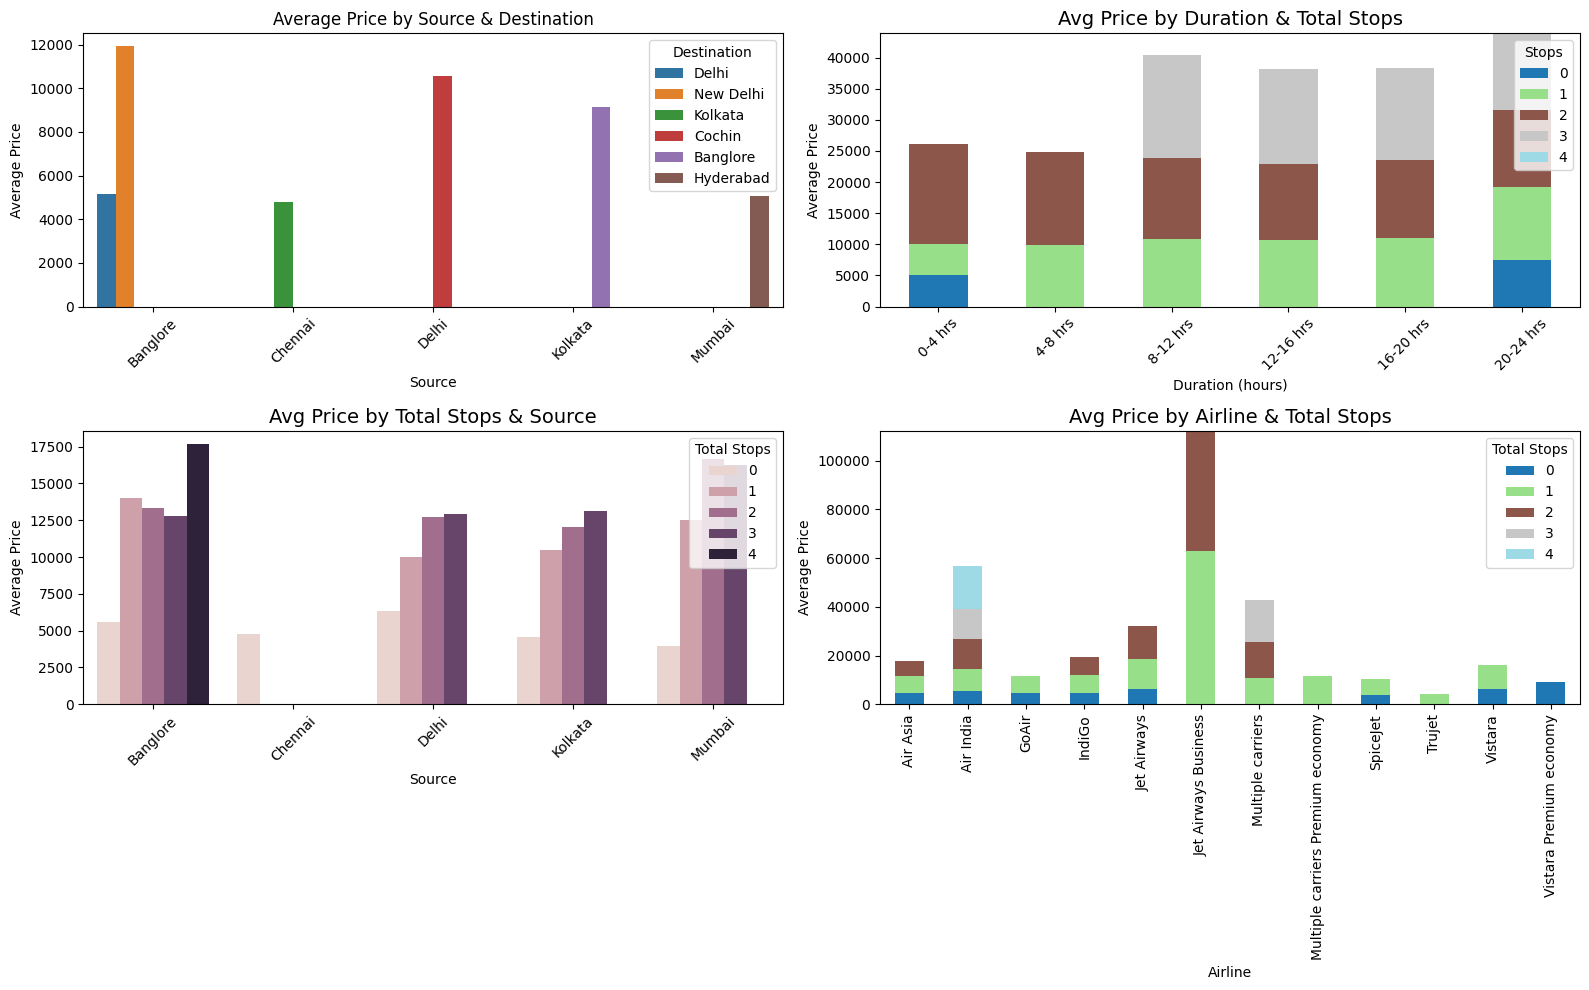

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

price_trend_sd = df.groupby(['Source','Destination'])['Price'].mean().reset_index()
sns.barplot(data=price_trend_sd, x='Source', y='Price', hue='Destination', ax=axes[0,0])
#hue='Destination': ဆိုက်ရောက်မြို့ (Destination) များကို အရောင်ခွဲ၍ (Legend) ဘေးချင်းယှဉ် တိုင်များအဖြစ် ပြသပါမည်။
axes[0,0].set_title('Average Price by Source & Destination')
axes[0,0].set_xlabel('Source')
axes[0,0].set_ylabel('Average Price')
axes[0,0].tick_params(axis='x', rotation=45)
# The legend will now be automatically generated by seaborn due to the 'hue' parameter.
# axes[0,0].legend(title='Destination') # Removed as 'hue' handles legend generation.

Price_trend_Stops_Duration = df.groupby(['Total_Stops','Duration_Bin'], observed=False)['Price'].mean().reset_index()
pivot_data = Price_trend_Stops_Duration.pivot(index='Duration_Bin', columns='Total_Stops', values='Price')
pivot_data.plot(kind='bar', stacked=True, colormap='tab20', ax=axes[0,1])
axes[0, 1].set_title('Avg Price by Duration & Total Stops', fontsize=14)
axes[0, 1].set_xlabel('Duration (hours)')
axes[0, 1].set_ylabel('Average Price')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].legend(title='Stops')

price_by_stops_source = df.groupby(['Total_Stops', 'Source'])['Price'].mean().reset_index()
sns.barplot(data=price_by_stops_source, x='Source', y='Price', hue='Total_Stops', ax=axes[1, 0])
axes[1, 0].set_title('Avg Price by Total Stops & Source', fontsize=14)
axes[1, 0].set_ylabel('Average Price')
axes[1, 0].set_xlabel('Source')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].legend(title='Total Stops')

# Replaced the previous plot on axes[1,1] with the new one: Avg Price by Airline & Total Stops
Price_trend_Airline = df.groupby(['Airline','Total_Stops'])['Price'].mean().unstack(fill_value=0)
Price_trend_Airline.plot(kind='bar', stacked=True, colormap='tab20', ax=axes[1,1])
axes[1, 1].set_title('Avg Price by Airline & Total Stops', fontsize=14)
axes[1, 1].set_xlabel('Airline')
axes[1, 1].set_ylabel('Average Price')
axes[1, 1].tick_params(axis='x', rotation=90)
axes[1, 1].legend(title='Total Stops')


plt.tight_layout()
plt.show()

In [32]:
stop_counts = df.groupby(['Source', 'Destination'])['Total_Stops'].value_counts().unstack(fill_value=0)



In [33]:
stop_counts


Total_Stops              0     1     2   3  4
Source   Destination                         
Banglore Delhi        1265     0     0   0  0
         New Delhi     287   562    75   7  1
Chennai  Kolkata       381     0     0   0  0
Delhi    Cochin        214  3185  1113  25  0
Kolkata  Banglore      724  1834   302  11  0
Mumbai   Hyderabad     621    44    30   2  0

In [34]:
df['Total_Stops'].unique()


array([0, 2, 1, 3, 4])

# ✈️ Flight Price Exploratory Data Analysis & Predictive Modeling

An end-to-end data science project analyzing key drivers of flight prices using statistical hypothesis testing, bivariate correlation, and multiple linear regression modeling.

---

## 📊 Exploratory Data Analysis (EDA) Visualization Grid

Below is the multi-panel distribution analysis showcasing flight price variations across route destinations, durations, layover stops, and airline carriers:

![Flight Price Analysis Visualizations](image_c531e1.png)

### Key Insights from EDA Visualizations:
1. **Average Price by Source & Destination (Top-Left):**
   - **Banglore $\rightarrow$ New Delhi** commands the highest average ticket fare (~12,000).
   - Direct flights from **Chennai** show the lowest baseline pricing (~5,000).
2. **Avg Price by Duration & Total Stops (Top-Right):**
   - Short flights (**0–4 hours**) consist primarily of non-stop or 1-stop options.
   - Long-duration journeys (**8–24 hours**) heavily feature 2-stop and 3-stop itineraries, significantly driving up total ticket costs.
3. **Avg Price by Total Stops & Departure Source (Bottom-Left):**
   - A consistent positive trend is observed across all sources (**Banglore, Delhi, Kolkata, Mumbai**): Fares scale upward directly as stops increase (**0 $\rightarrow$ 1 $\rightarrow$ 2 $\rightarrow$ 3/4**).
4. **Avg Price by Airline & Total Stops (Bottom-Right):**
   - **Jet Airways Business** acts as a major premium outlier, with average prices exceeding **100,000**.
   - Budget carriers (**IndiGo, SpiceJet, AirAsia, GoAir**) maintain consistent lower-tier pricing under **20,000**.

---

## 📌 Statistical & Regression Modeling Summary

### 1. Bivariate Correlation Matrix
| Feature Comparison | Correlation Coefficient ($r$) | Relationship Strength |
| :--- | :---: | :--- |
| **Total_Stops vs. Price** | `0.603891` | Strong Positive |
| **Duration_mins vs. Price** | `0.503710` | Moderate Positive |

### 2. Multiple Linear Regression Model
**Features:** `Duration_mins` + `Stops_num` $\rightarrow$ **Target:** `Price`

- **Overall Model Variance Explained ($R^2$ Score):** **`0.35057`** ($35.06\%$)
- **Single Feature ($Duration\_mins$) $R^2$:** **`0.24838`** ($24.84\%$)

```text
Price = 5426.36 + (1.21 × Duration_mins) + (3493.09 × Stops_num)